In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [12]:
def get_nearest_index(array, value):
    return np.abs(array - value).argmin()

def extract_transect_3000km(ds, lat_value, lon_start, var='obp_rm_dt'):
    dx_total_km = 3000
    dx_deg = dx_total_km / (111.32 * np.cos(np.radians(lat_value)))
    lon_end = lon_start + dx_deg
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    lat_idx = get_nearest_index(ds.lat.values, lat_value)
    return ds[var].sel(lon=slice(lon_start, lon_end)).isel(lat=lat_idx)

def compute_km_spacing(lon_array, lat_value):
    distances = []
    for i in range(len(lon_array) - 1):
        p1 = (lat_value, lon_array[i])
        p2 = (lat_value, lon_array[i + 1])
        distances.append(geodesic(p1, p2).kilometers)
    return np.mean(distances)

In [3]:
ds1 = xr.open_dataset('/glade/work/netige/Data/VIKING/viking_obp_ssh_msc_residuals.nc')
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

In [ ]:
with ProgressBar():
    djf_ds = viking_ds.where(viking_ds['time'].dt.month.isin([12, 1, 2]), drop=True).compute()
    jja_ds = viking_ds.where(viking_ds['time'].dt.month.isin([6,7,8]), drop=True).compute()

In [5]:
raw_obp = viking_ds["obp_rm_dt"]          # (time, lat, lon)
with ProgressBar():
    std_raw = raw_obp.std(dim="time", skipna=True).compute()

In [7]:
transects = {
    "GS":   {"name": "GS", "lat": 38, "lon": -72},   # Gulf Stream
    "GL":   {"name": "GL", "lat": 58, "lon": -58},   # Kuroshio Extension
    #"TP":   {"name": "TP", "lat": 0,  "lon": -170},  # Tropical Pacific
    "TA":   {"name": "TA", "lat": 0,  "lon": -25},   # Tropical Atlantic
    "ENA":  {"name": "ENA", "lat": 40, "lon": -45},   # Eastern North Atlantic
    #"ENP":  {"name": "ENP", "lat": 35, "lon": -160},  # Eastern North Pacific
    #"Pat":  {"name": "Pat", "lat": -45, "lon": -60},  # Patagonian Shelf
    #"Agul": {"name": "Agul", "lat": -38, "lon": 0},   # Agulhas Current
    #"SO1":  {"name": "SO1", "lat": -58, "lon": 0},    # Southern Ocean 1
    #"SO2":  {"name": "SO2", "lat": -57, "lon": 90},   # Southern Ocean 2
    #"SO3":  {"name": "SO3", "lat": -62, "lon": -120},  # Southern Ocean 3
    #"Arctic": {"name": "Arctic", "lat": 80, "lon": -10},   # Arctic transect
    #"NPML": {"name": "NPML", "lat": 15, "lon": -170},   # Arctic transect
    #"SPML": {"name": "SPML", "lat": -20, "lon": -170},   # Arctic transect
    "NAML": {"name": "NAML", "lat": 20, "lon": -46},   # Arctic transect
    "SAML": {"name": "SAML", "lat": -20, "lon": -38},   # Arctic transect
}


In [8]:
transect_lines = {}

for name, loc in transects.items():
    transect = extract_transect_3000km(viking_ds, lat_value=loc["lat"], lon_start=loc["lon"], var='obp_rm_dt')
    transect_lines[name] = {
        "lon": transect.lon.values,
        "lat": np.full_like(transect.lon.values, loc["lat"])
    }


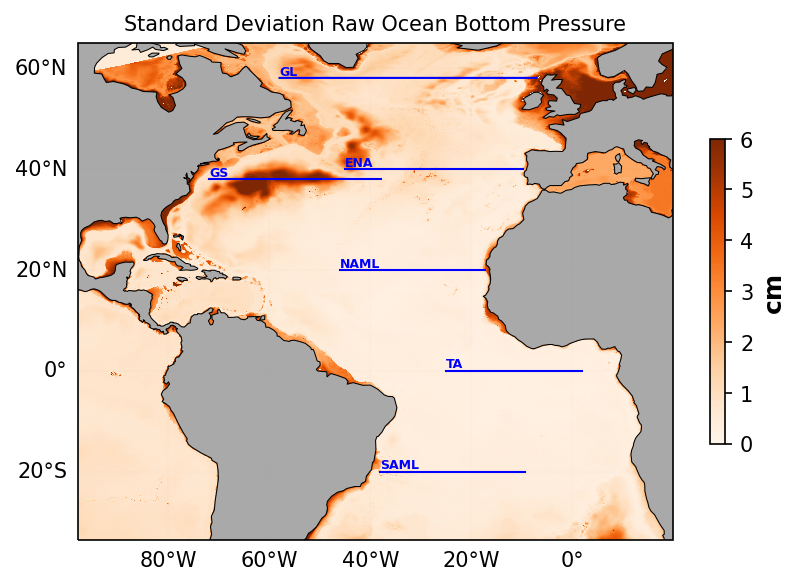

In [9]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

ds = std_raw  # assume this contains .latitude, .longitude, .pbo

fig = plt.figure(dpi=150)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=0))

# Background map
pc = ax.pcolormesh(ds.lon, ds.lat, ds,
                   transform=ccrs.PlateCarree(), cmap='Oranges', vmin=0, vmax=6)

#ax.set_global()
gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
gl.xlabels_bottom = True
gl.ylabels_left = True

# Add land
ax.add_feature(cartopy.feature.NaturalEarthFeature(
    'physical', 'land', '110m', linewidth=0.5, edgecolor='black', facecolor='darkgray'))

# Plot transects in white + annotate each
for name, line in transect_lines.items():
    ax.plot(line["lon"], line["lat"], transform=ccrs.PlateCarree(),
            lw=1, color='blue')

    # Annotate near the start of the line
    ax.text(line["lon"][0], line["lat"][0], name,
            transform=ccrs.PlateCarree(),
            fontsize=6, color='blue', ha='left', va='bottom', fontweight = 'bold',
            path_effects=[])

# Colorbar and title
cb = plt.colorbar(pc, shrink=0.55)
cb.set_label("cm", fontsize=12, fontweight="bold")

plt.title("Standard Deviation Raw Ocean Bottom Pressure", fontsize=10)
#plt.savefig("VIKING_zonal_transects.png", dpi=500, bbox_inches='tight')
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------------- Helpers -------------------

def get_nearest_index(array, value):
    return np.abs(array - value).argmin()

def extract_transect_3000km(ds, lat_value, lon_start, var='zos'):
    dx_total_km = 3000
    dx_deg = dx_total_km / (111.32 * np.cos(np.radians(lat_value)))
    lon_end = lon_start + dx_deg
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    lat_idx = get_nearest_index(ds.lat.values, lat_value)
    return ds[var].sel(lon=slice(lon_start, lon_end)).isel(lat=lat_idx)

def compute_km_spacing(lon_array, lat_value):
    distances = []
    for i in range(len(lon_array) - 1):
        p1 = (lat_value, lon_array[i])
        p2 = (lat_value, lon_array[i + 1])
        distances.append(geodesic(p1, p2).kilometers)
    return np.mean(distances)

def compute_physical_psd(transect_array, dx_km, window=None):
    """
    Compute averaged 1D power spectral density (PSD) from a 2D array (time x space),
    using correct normalization and optional windowing.

    Parameters
    ----------
    transect_array : ndarray
        2D array of shape (time, space).
    dx_km : float
        Grid spacing in kilometers.
    window : str or None
        Optional window function to apply. Supported: 'hanning', None.

    Returns
    -------
    psd_avg : ndarray
        Averaged PSD (1D), units of (data unit)^2 * km.
    """
    psd_list = []
    
    for row in transect_array:
        if not np.all(np.isnan(row)):
            row = row - np.nanmean(row)
            row_filled = np.nan_to_num(row)

            N = len(row_filled)

            if window == 'hanning':
                win = np.hanning(N)
            else:
                win = np.ones(N)

            row_win = row_filled * win
            fft_vals = np.fft.fft(row_win)
            psd = (np.abs(fft_vals) ** 2) * dx_km / np.sum(win ** 2)
            psd_list.append(psd)

    if not psd_list:
        raise ValueError("All rows are NaN.")

    return np.mean(np.stack(psd_list), axis=0)

# ------------------- Main Plot -------------------


def plot_spectrum_and_map_3000km(bp_data, ssh_data, lat_value, lon_start, transect_name, var='zos', window=None,
                                save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import scipy.stats as stats

    fig = plt.figure(figsize=(7, 6))

    # --- Spectrum panel only ---
    ax_spec = fig.add_subplot(1, 1, 1)
    ax_spec.set_title(f"Zonal Power Spectrum along {transect_name} for SSH")
    ax_spec.set_xlabel("Zonal Wavenumber (cycles/km)")
    ax_spec.set_ylabel("Power (cm² per cycles/km)")
    ax_spec.set_xscale('log')
    ax_spec.set_yscale('log')
    ax_spec.grid(True, which='both', linestyle='--', alpha=0.5)

    annotations = []

    for label, ds in datasets.items():
        try:
            transect = extract_transect_3000km(ds, lat_value, lon_start, var=var)
            longitudes = transect.lon.values
            dx_km = compute_km_spacing(longitudes, lat_value)
            psd = compute_physical_psd(transect.values, dx_km, window=window)

            N = psd.size
            freqs = np.fft.fftfreq(N, d=dx_km)
            pos_mask = freqs > 0
            freqs = freqs[pos_mask]
            psd = psd[pos_mask]
            dk = np.diff(freqs).mean()

            ax_spec.plot(freqs, psd, lw=1.5, label=label)

            if label.lower() == 'raw':
                # --- Proper spectral-space variance integration ---
                total_variance = 2 * np.sum(psd) * dk

                short_wave_mask = freqs >= 1 / 600  # wavelengths < 600 km
                short_wave_variance = 2 * np.sum(psd[short_wave_mask]) * dk

                ratio = short_wave_variance / total_variance if total_variance > 0 else np.nan
                percent = 100 * ratio if not np.isnan(ratio) else np.nan

                annotations.append(
                    f"Variance <600 km: {short_wave_variance:.2f} cm² | Total: {total_variance:.2f} cm²\n"
                    f"Ratio: {ratio:.2f} ({percent:.1f}%)"
                )

                # --- Fit slope between 100–500 km (wavenumber range 1/500 to 1/100) ---
                slope_mask = (freqs >= 1 / 300) & (freqs <= 1 / 100)
                if np.sum(slope_mask) >= 3:
                    x_fit = np.log10(freqs[slope_mask])
                    y_fit = np.log10(psd[slope_mask])
                    slope, intercept, _, _, _ = stats.linregress(x_fit, y_fit)

                    # Plot the fitted power-law line
                    freqs_fit = freqs[slope_mask]
                    psd_fit = 10 ** (slope * np.log10(freqs_fit) + intercept)
                    ax_spec.plot(freqs_fit, psd_fit, color='black', lw=2, linestyle='--')
                    annotations.append(f"Slope (100–300 km): {slope:.2f}")

        except Exception as e:
            print(f"{label} failed: {e}")

    # Add annotation to bottom-left of spectral plot
    if annotations:
        ax_spec.text(0.02, 0.05, "\n".join(annotations),
                     transform=ax_spec.transAxes,
                     fontsize=9,
                     verticalalignment='bottom',
                     horizontalalignment='left',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax_spec.legend()
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
        plt.close(fig)
    else:
        plt.show()
        


In [21]:
def plot_spectrum_comparison_ssh_bp(
    datasets_ssh,
    datasets_bp,
    lat_value,
    lon_start,
    transect_name,
    window=None,
    save_path=None
):
    import matplotlib.pyplot as plt
    import numpy as np
    import scipy.stats as stats

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_title(f"Zonal Power Spectrum along {transect_name} DJF")
    ax.set_xlabel("Zonal Wavenumber (cycles/km)")
    ax.set_ylabel("Power (cm² per cycles/km)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    annotations_ssh = []
    annotations_bp = []

    # --- SSH Loop ---
    for label, ds in datasets_ssh.items():
        try:
            transect = extract_transect_3000km(ds, lat_value, lon_start, var="ssh_rm_dt")
            dx_km = compute_km_spacing(transect.lon.values, lat_value)
            psd = compute_physical_psd(transect.values, dx_km, window=window)
            freqs = np.fft.fftfreq(psd.size, d=dx_km)
            freqs, psd = freqs[freqs > 0], psd[freqs > 0]
            dk = np.diff(freqs).mean()

            ax.plot(freqs, psd, label=f"{label} SSH", lw=1.5)

            if label.lower() == 'raw':
                total_var = 2 * np.sum(psd) * dk
                short_mask = freqs >= 1 / 600
                short_var = 2 * np.sum(psd[short_mask]) * dk
                ratio = short_var / total_var if total_var > 0 else np.nan
                percent = 100 * ratio if not np.isnan(ratio) else np.nan

                annotations_ssh.append(
                    f"SSH {label}: <600km = {short_var:.2f} cm² | Total = {total_var:.2f} | {percent:.1f}%"
                )

                slope_mask = (freqs >= 1 / 300) & (freqs <= 1 / 100)
                if np.sum(slope_mask) >= 3:
                    x_fit = np.log10(freqs[slope_mask])
                    y_fit = np.log10(psd[slope_mask])
                    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
                    psd_fit = 10 ** (slope * x_fit + intercept)
                    ax.plot(10 ** x_fit, psd_fit, color='black', lw=2, linestyle='--')
                    annotations_ssh.append(f"SSH Slope (100–300 km): {slope:.2f}")

        except Exception as e:
            print(f"SSH {label} failed: {e}")

    # --- BP Loop ---
    for label, ds in datasets_bp.items():
        try:
            transect = extract_transect_3000km(ds, lat_value, lon_start, var="obp_rm_dt")
            dx_km = compute_km_spacing(transect.lon.values, lat_value)
            psd = compute_physical_psd(transect.values, dx_km, window=window)
            freqs = np.fft.fftfreq(psd.size, d=dx_km)
            freqs, psd = freqs[freqs > 0], psd[freqs > 0]
            dk = np.diff(freqs).mean()

            ax.plot(freqs, psd, label=f"{label} BP", lw=1.5, linestyle='-')

            if label.lower() == 'raw':
                total_var = 2 * np.sum(psd) * dk
                short_mask = freqs >= 1 / 600
                short_var = 2 * np.sum(psd[short_mask]) * dk
                ratio = short_var / total_var if total_var > 0 else np.nan
                percent = 100 * ratio if not np.isnan(ratio) else np.nan

                annotations_bp.append(
                    f"BP {label}: <600km = {short_var:.2f} cm² | Total = {total_var:.2f} | {percent:.1f}%"
                )

                slope_mask = (freqs >= 1 / 300) & (freqs <= 1 / 100)
                if np.sum(slope_mask) >= 3:
                    x_fit = np.log10(freqs[slope_mask])
                    y_fit = np.log10(psd[slope_mask])
                    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
                    psd_fit = 10 ** (slope * x_fit + intercept)
                    ax.plot(10 ** x_fit, psd_fit, color='black', lw=2, linestyle='--')
                    annotations_bp.append(f"BP Slope (100–300 km): {slope:.2f}")

        except Exception as e:
            print(f"BP {label} failed: {e}")

    # --- Add Text Box with Annotations ---
    text_str = "\n".join(annotations_ssh + [""] + annotations_bp)
    ax.text(0.02, 0.03, text_str, transform=ax.transAxes,
            fontsize=8, va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.legend()
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
        plt.show()
    else:
        plt.show()


In [22]:
ssh = viking_ds["ssh_rm_dt"] 
bp = viking_ds["obp_rm_dt"] 

In [6]:
datasets_ssh = {
    "Raw": djf_ds          # e.g. 0.25°
    #"1°": GLORYS_ssh_1deg,
    #"3°": GLORYS_ssh_3deg
}

datasets_bp = {
    "Raw": djf_ds      # e.g. 0.25°
    #"1°": GLORYS_bp_1deg,
    #"3°": GLORYS_bp_3deg
}

In [25]:
info = transects["GS"]
info

{'name': 'GS', 'lat': 38, 'lon': -72}

Running transect: GS
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_GS_DJF.png


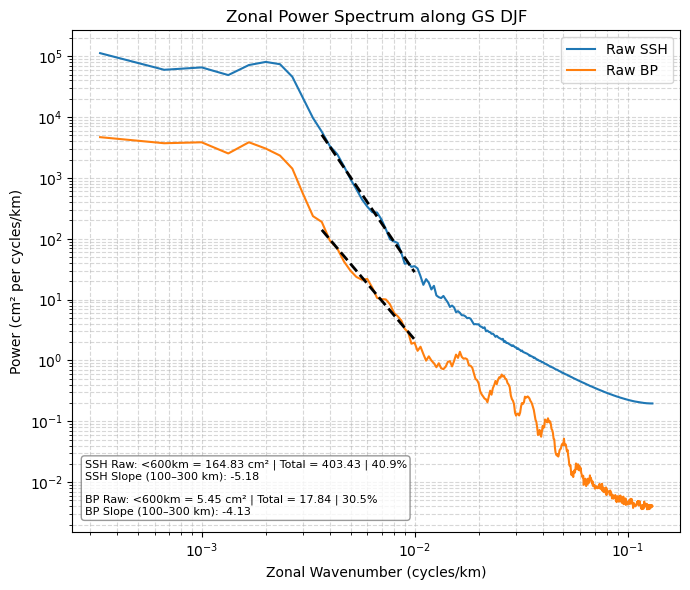

Running transect: GL
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_GL_DJF.png


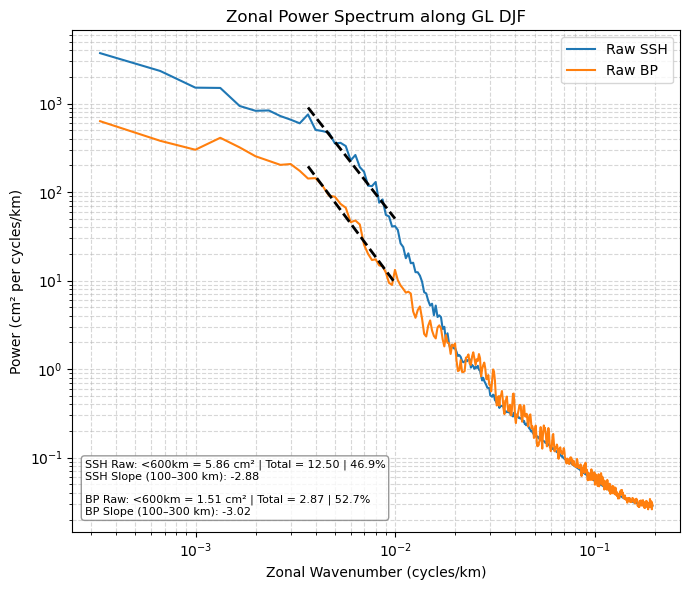

Running transect: TA
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_TA_DJF.png


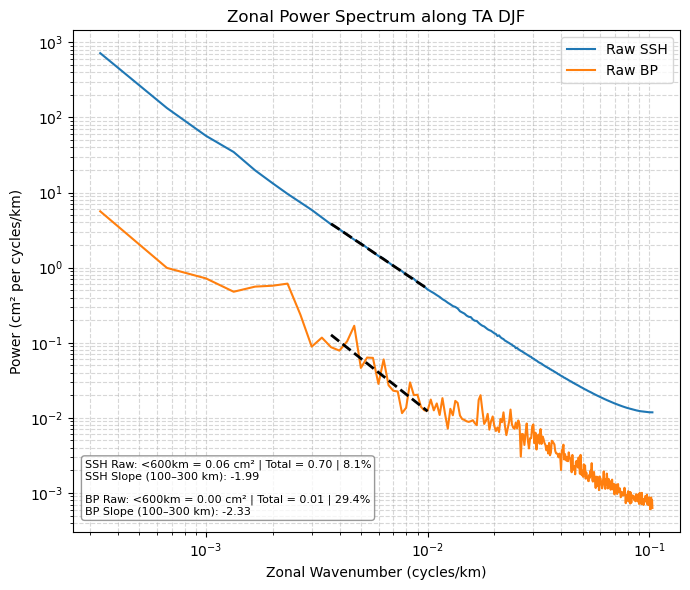

Running transect: ENA
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_ENA_DJF.png


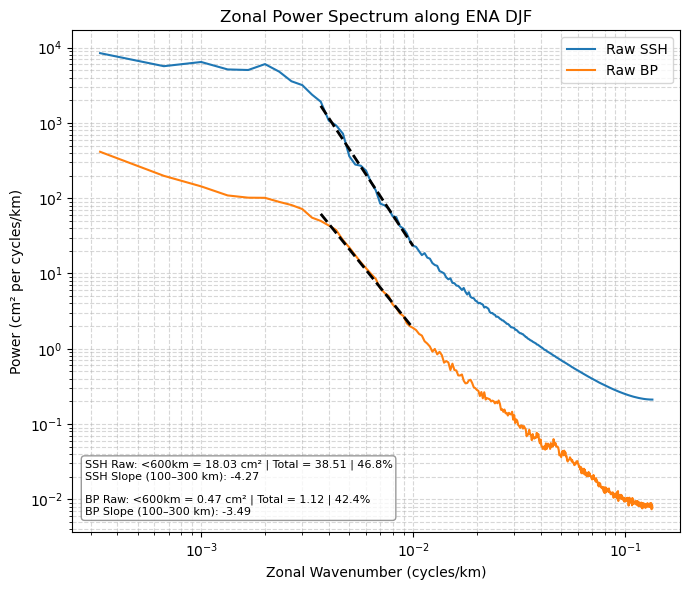

Running transect: NAML
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_NAML_DJF.png


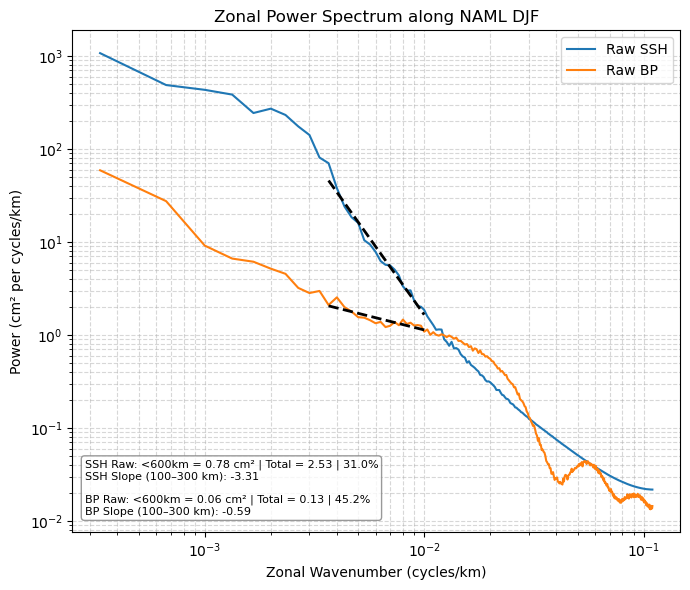

Running transect: SAML
Saved plot to ./VIKING_WNS/zon_comp_transect_spectrum_SAML_DJF.png


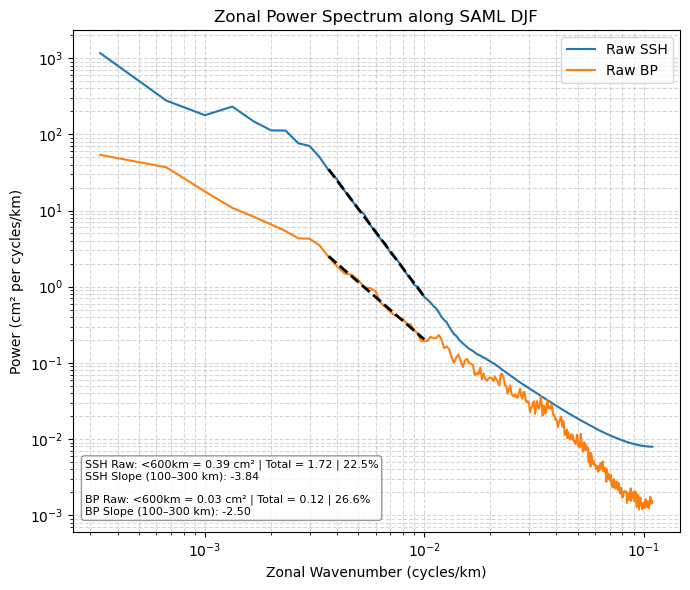

In [26]:
for name, info in transects.items():
    print(f"Running transect: {name}")
    output_file = f"./VIKING_WNS/zon_comp_transect_spectrum_{name}_DJF.png"
    plot_spectrum_comparison_ssh_bp(
        datasets_ssh,
        datasets_bp,
        lat_value=info['lat'],
        lon_start=info['lon'],
        transect_name=info['name'],  # same as name
        window=None,
        save_path=output_file
    )


### Meridional Transects

In [7]:
def extract_transect_3000km_meridional(ds, lon_value, lat_start, var='pbo_cm'):
    dy_total_km = 3000
    dy_deg = dy_total_km / 111.32
    lat_end = lat_start + dy_deg

    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lat')

    lon_idx = get_nearest_index(ds.lon.values, lon_value)
    return ds[var].sel(lat=slice(lat_start, lat_end)).isel(lon=lon_idx)

def compute_km_spacing_lat(lat_array, lon_value):
    from geopy.distance import geodesic
    distances = []
    for i in range(len(lat_array) - 1):
        p1 = (lat_array[i], lon_value)
        p2 = (lat_array[i + 1], lon_value)
        distances.append(geodesic(p1, p2).kilometers)
    return np.mean(distances)


In [8]:
import numpy as np

# Use your existing dictionary
transects = {
    "WNA":   {"name": "WNA", "lat": 15, "lon": -60},
    "CNA":   {"name": "CNA", "lat": 15, "lon": -45},
    "ENA":   {"name": "ENA", "lat": 15,  "lon": -20},
    "TA":   {"name": "TA", "lat": -15,  "lon": -27},
    "MLA1":   {"name": "MLA1", "lat": 30,  "lon": -35},
    "MLA2":  {"name": "MLA2", "lat": 30, "lon": -15},
    #"CNP2":  {"name": "CNP2", "lat": 15, "lon": -170},
    #"ENP":  {"name": "ENP", "lat": 15, "lon": -140},
    "WSA":   {"name": "WSA", "lat": -30, "lon": -32},
    "CSA":   {"name": "CSA", "lat": -30, "lon": -15},
    "ESA":   {"name": "ESA", "lat": -30,  "lon": 5},
    #"WSP":   {"name": "WSP", "lat": -45,  "lon": 165},
    #"CSP1":  {"name": "CSP1", "lat": -45, "lon": -170},
    #"CSP2":  {"name": "CSP2", "lat": -45, "lon": -140},
    #"ESP1":  {"name": "ESP1", "lat": -45, "lon": -110},
    #"ESP2":  {"name": "ESP2", "lat": -45, "lon": -90},
    #"TP1":  {"name": "TP1", "lat": -15, "lon": -150},
    #"TP2":  {"name": "TP2", "lat": -15, "lon": -130},
    #"TP3":  {"name": "TP3", "lat": -15, "lon": -110},
    #"IO1":  {"name": "IO1", "lat": -45, "lon": 60},
    #"IO2":  {"name": "IO2", "lat": -45, "lon": 80},
    #"IO3":  {"name": "IO3", "lat": -45, "lon": 100},
    #"ARB":  {"name": "ARB", "lat": -15, "lon": 65},
    #"BOB":  {"name": "BOB", "lat": -15, "lon": 90},
    #"SO1":  {"name": "SO1", "lat": -65, "lon": -155},
    #"SO2":  {"name": "SO2", "lat": -65, "lon": -115},
    #"SO3":  {"name": "SO3", "lat": -65, "lon": -40},
    #"SO4":  {"name": "SO4", "lat": -67, "lon": 30},
    #"SO5":  {"name": "SO5", "lat": -65, "lon": 75},
    #"SO6":  {"name": "SO6", "lat": -65, "lon": 130},
    #"IO5":  {"lat": -30, "lon": 80},
    #"Agul": {"lat": -38, "lon": 0},
    #"SO1":  {"lat": -58, "lon": 0},
    #"SO2":  {"lat": -57, "lon": 90},
    #"SO3":  {"lat": -62, "lon": -120},
    #"Arctic": {"lat": 80, "lon": -10},
    #"NPML": {"lat": 15, "lon": -170},
    #"SPML": {"lat": -20, "lon": -170},
    #"NAML": {"lat": 20, "lon": -46},
    #"SAML": {"lat": -20, "lon": -40},
}

# Parameters for meridional transect
dy_km = 3000
dy_deg = dy_km / 111.32  # km to degrees latitude
n_points = 100

# Build meridional transect lines (northward only)
transect_lines = {}

for name, loc in transects.items():
    lat_start = loc["lat"]
    lat_end = lat_start + dy_deg  # Extend northward only
    lat_vals = np.linspace(lat_start, lat_end, n_points)
    lon_vals = np.full_like(lat_vals, loc["lon"])

    transect_lines[name] = {
        "lat": lat_vals,
        "lon": lon_vals
    }


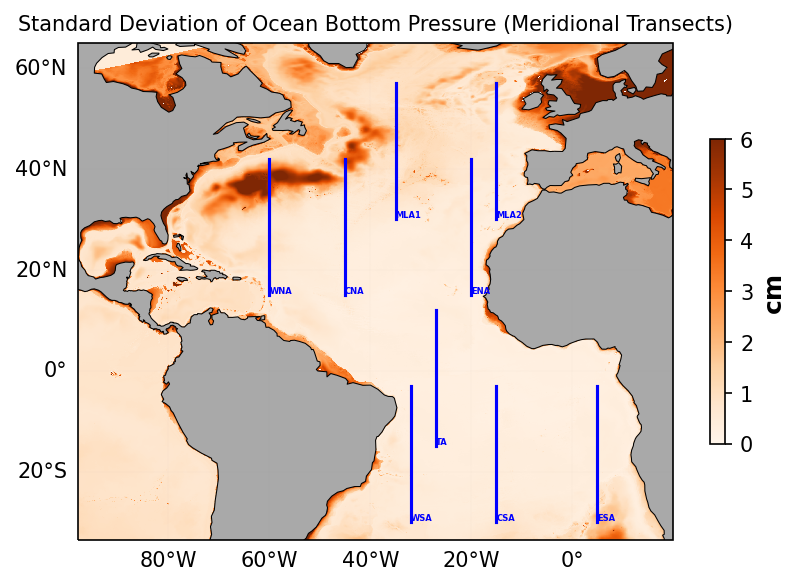

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

ds = std_raw  # assumes .latitude, .longitude, .pbo_cm

fig = plt.figure(dpi=150)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=0))

# Background map
pc = ax.pcolormesh(ds.lon, ds.lat, ds,
                   transform=ccrs.PlateCarree(), cmap='Oranges', vmin=0, vmax=6)

#ax.set_global()
gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
gl.xlabels_bottom = True
gl.ylabels_left = True

# Add land
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'land', '110m', linewidth=0.5, edgecolor='black', facecolor='darkgray'))

# Plot meridional transects (constant lon, varying lat)
for name, line in transect_lines.items():
    ax.plot(line["lon"], line["lat"], transform=ccrs.PlateCarree(),
            lw=1.5, color='blue')

    # Annotate near the southernmost point
    ax.text(line["lon"][0], line["lat"][0], name,
            transform=ccrs.PlateCarree(),
            fontsize=4, color='blue', ha='left', va='bottom', fontweight='bold',
            path_effects=[])

# Colorbar and title
cb = plt.colorbar(pc, shrink=0.55)
cb.set_label("cm", fontsize=12, fontweight="bold")

plt.title("Standard Deviation of Ocean Bottom Pressure (Meridional Transects)", fontsize=10)
#plt.savefig("VIKING_meridional_transects.png", dpi=500, bbox_inches='tight')
plt.show()


In [10]:
def plot_meridional_spectrum_comparison_ssh_bp(
    datasets_ssh,
    datasets_bp,
    lon_value,
    lat_start,
    transect_name,
    window=None,
    save_path=None
):
    import matplotlib.pyplot as plt
    import numpy as np
    import scipy.stats as stats

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_title(f"Meridional Power Spectrum along {transect_name} DJF")
    ax.set_xlabel("Meridional Wavenumber (cycles/km)")
    ax.set_ylabel("Power (cm² per cycles/km)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    annotations_ssh = []
    annotations_bp = []

    # --- SSH Loop ---
    for label, ds in datasets_ssh.items():
        try:
            transect = extract_transect_3000km_meridional(ds, lon_value, lat_start, var="ssh_rm_dt")
            dy_km = compute_km_spacing_lat(transect.lat.values, lon_value)
            psd = compute_physical_psd(transect.values, dy_km, window=window)
            freqs = np.fft.fftfreq(psd.size, d=dy_km)
            freqs, psd = freqs[freqs > 0], psd[freqs > 0]
            dk = np.diff(freqs).mean()

            ax.plot(freqs, psd, label=f"{label} SSH", lw=1.5)

            if label.lower() == 'raw':
                total_var = 2 * np.sum(psd) * dk
                short_mask = freqs >= 1 / 600
                short_var = 2 * np.sum(psd[short_mask]) * dk
                ratio = short_var / total_var if total_var > 0 else np.nan
                percent = 100 * ratio if not np.isnan(ratio) else np.nan

                annotations_ssh.append(
                    f"SSH {label}: <600km = {short_var:.2f} cm² | Total = {total_var:.2f} | {percent:.1f}%"
                )

                slope_mask = (freqs >= 1 / 300) & (freqs <= 1 / 100)
                if np.sum(slope_mask) >= 3:
                    x_fit = np.log10(freqs[slope_mask])
                    y_fit = np.log10(psd[slope_mask])
                    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
                    psd_fit = 10 ** (slope * x_fit + intercept)
                    ax.plot(10 ** x_fit, psd_fit, color='black', lw=2, linestyle='--')
                    annotations_ssh.append(f"SSH Slope (100–300 km): {slope:.2f}")

        except Exception as e:
            print(f"SSH {label} failed: {e}")

    # --- BP Loop ---
    for label, ds in datasets_bp.items():
        try:
            transect = extract_transect_3000km_meridional(ds, lon_value, lat_start, var="obp_rm_dt")
            dy_km = compute_km_spacing_lat(transect.lat.values, lon_value)
            psd = compute_physical_psd(transect.values, dy_km, window=window)
            freqs = np.fft.fftfreq(psd.size, d=dy_km)
            freqs, psd = freqs[freqs > 0], psd[freqs > 0]
            dk = np.diff(freqs).mean()

            ax.plot(freqs, psd, label=f"{label} BP", lw=1.5, linestyle='-')

            if label.lower() == 'raw':
                total_var = 2 * np.sum(psd) * dk
                short_mask = freqs >= 1 / 600
                short_var = 2 * np.sum(psd[short_mask]) * dk
                ratio = short_var / total_var if total_var > 0 else np.nan
                percent = 100 * ratio if not np.isnan(ratio) else np.nan

                annotations_bp.append(
                    f"BP {label}: <600km = {short_var:.2f} cm² | Total = {total_var:.2f} | {percent:.1f}%"
                )

                slope_mask = (freqs >= 1 / 300) & (freqs <= 1 / 100)
                if np.sum(slope_mask) >= 3:
                    x_fit = np.log10(freqs[slope_mask])
                    y_fit = np.log10(psd[slope_mask])
                    slope, intercept, *_ = stats.linregress(x_fit, y_fit)
                    psd_fit = 10 ** (slope * x_fit + intercept)
                    ax.plot(10 ** x_fit, psd_fit, color='black', lw=2, linestyle='--')
                    annotations_bp.append(f"BP Slope (100–300 km): {slope:.2f}")

        except Exception as e:
            print(f"BP {label} failed: {e}")

    # --- Add Text Box with Annotations ---
    text_str = "\n".join(annotations_ssh + [""] + annotations_bp)
    ax.text(0.02, 0.03, text_str, transform=ax.transAxes,
            fontsize=8, va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.legend()
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
        plt.show()
    else:
        plt.show()


Running transect: WNA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_WNA_DJF.png


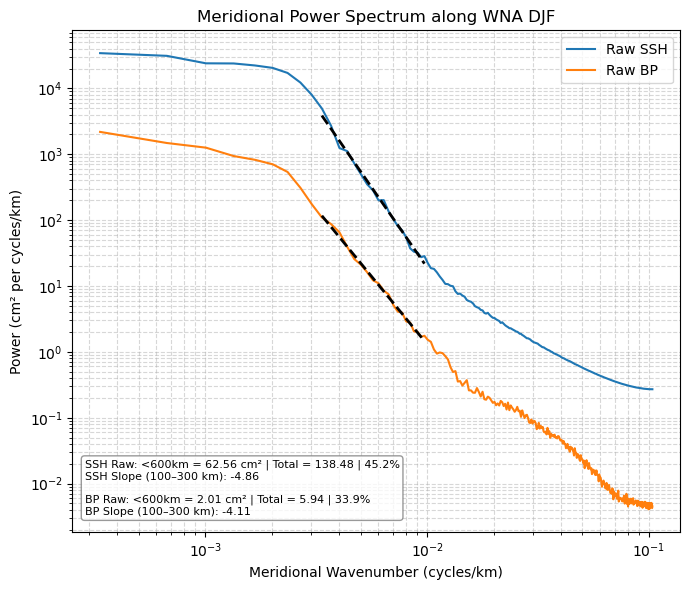

Running transect: CNA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_CNA_DJF.png


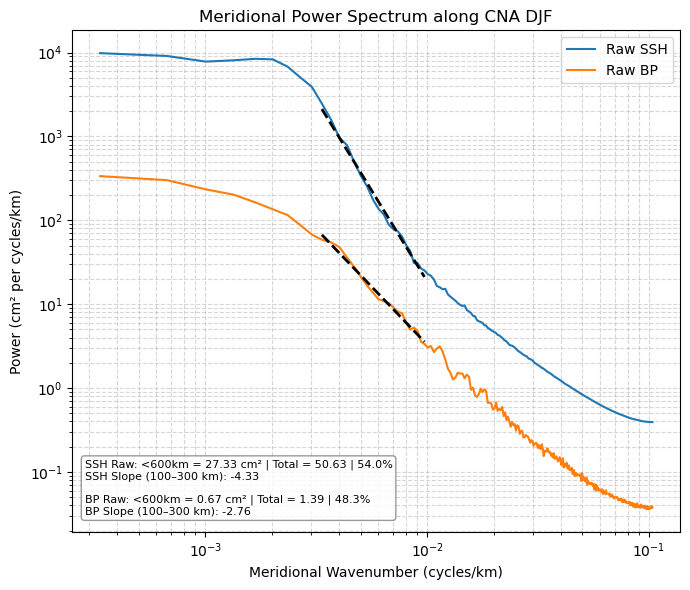

Running transect: ENA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_ENA_DJF.png


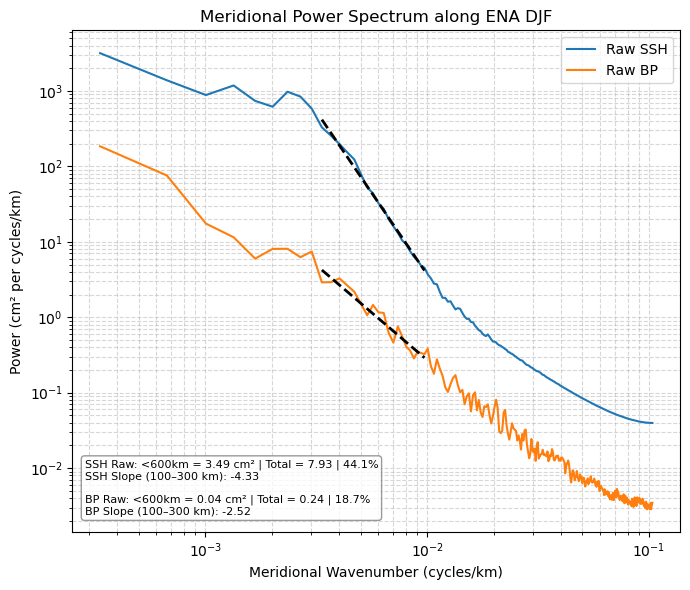

Running transect: TA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_TA_DJF.png


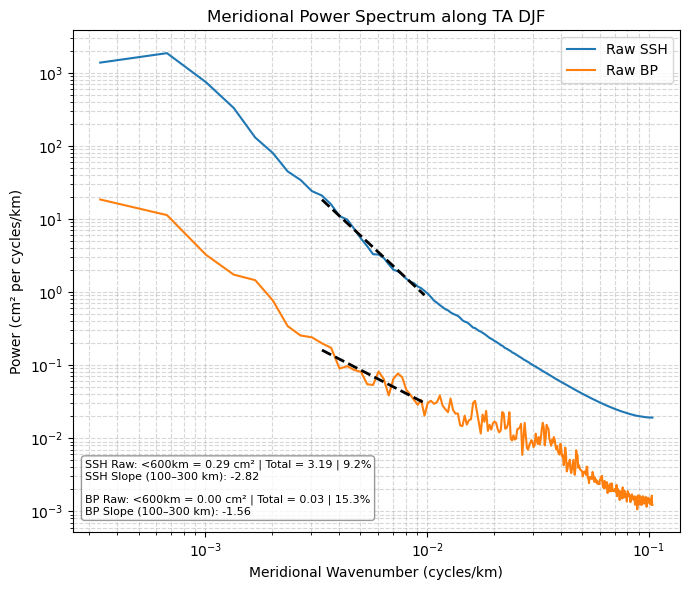

Running transect: MLA1
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_MLA1_DJF.png


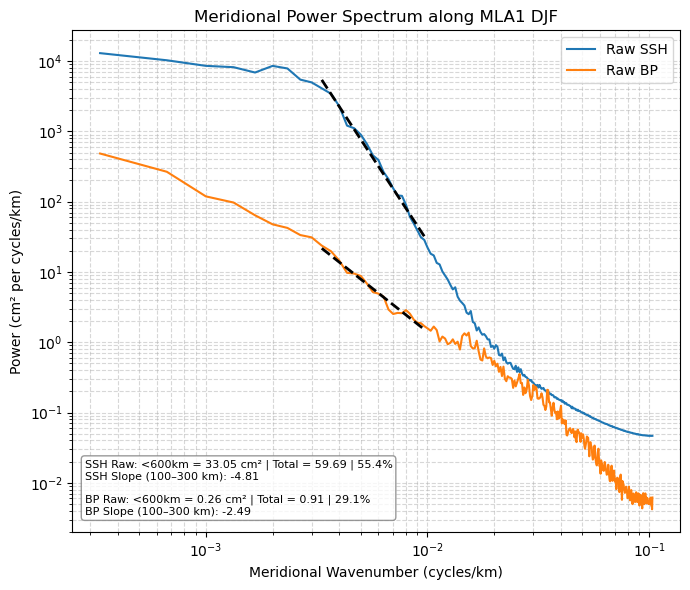

Running transect: MLA2
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_MLA2_DJF.png


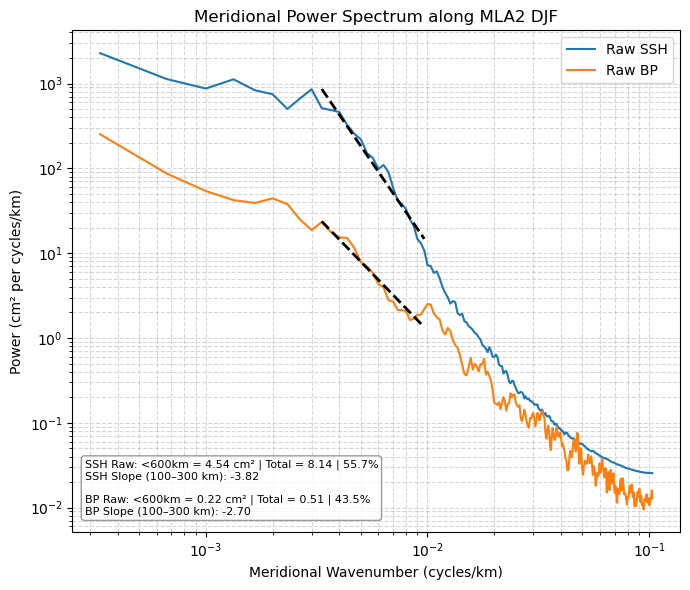

Running transect: WSA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_WSA_DJF.png


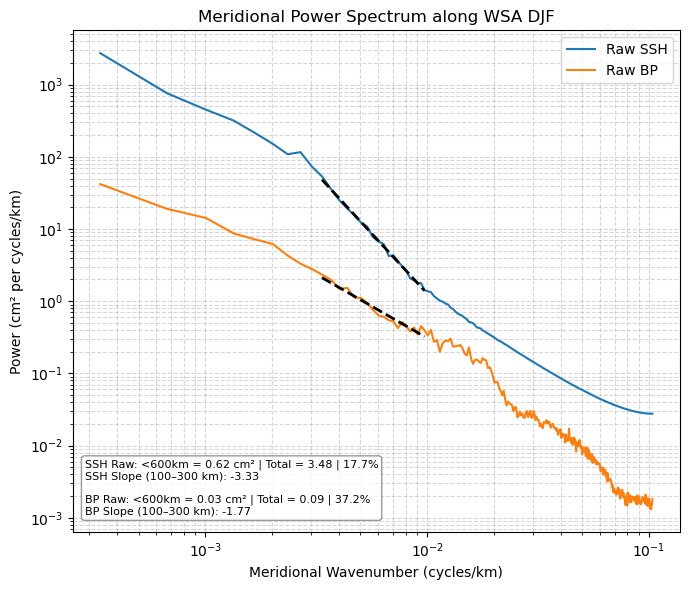

Running transect: CSA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_CSA_DJF.png


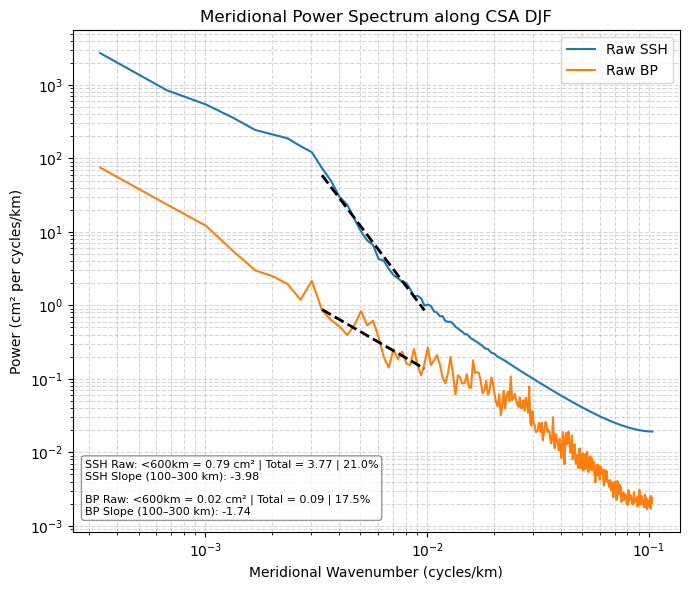

Running transect: ESA
Saved plot to ./VIKING_WNS/merd_comp_transect_spectrum_ESA_DJF.png


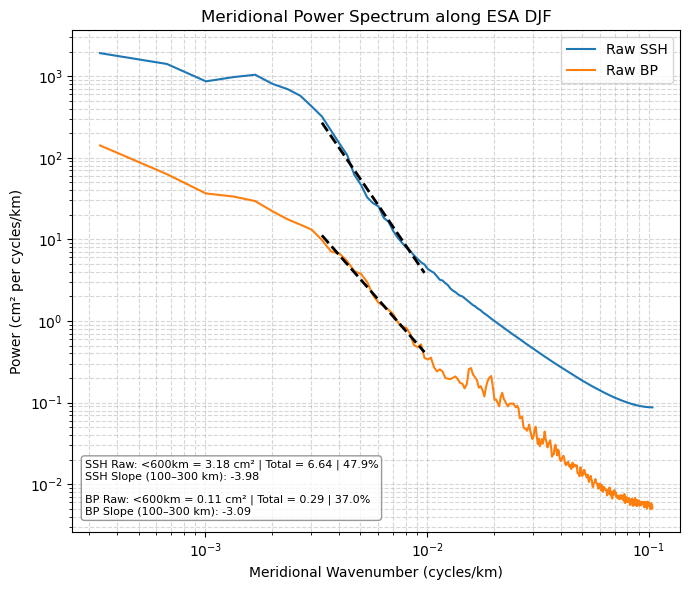

In [14]:
for name, info in transects.items():
    print(f"Running transect: {name}")
    output_file = f"./VIKING_WNS/merd_comp_transect_spectrum_{name}_DJF.png"
    plot_meridional_spectrum_comparison_ssh_bp(
        datasets_ssh,
        datasets_bp,
        lon_value=info['lon'],
        lat_start=info['lat'],
        transect_name=info['name'],
        window=None,
        save_path=output_file
    )
